In [1]:
# --- CELL 1: SETUP ---
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Set your API Key (Replace with your own or use an .env file)
# os.environ["OPENAI_API_KEY"] = "your-key-here"
os.environ["GOOGLE_API_KEY"] = "your-key-here"

print("✅ Setup Complete")

✅ Setup Complete


In [2]:
# --- CELL 2: THE SHARED CLIPBOARD (STATE) ---
class SentinelState(TypedDict):
    user_request: str
    plan: List[str]      # The list of tasks the Coordinator creates
    results: List[str]   # The output from each completed task
    final_report: str

In [3]:
# --- CELL 3: THE WORKERS (NODES) ---

def coordinator_node(state: SentinelState):
    print("📋 Coordinator: Creating execution plan...")
    # Simulating a "Brain" that breaks down a request
    # In a real app, an LLM would generate this list
    plan = ["fetch_data", "analyze_sentiment", "format_output"]
    return {"plan": plan, "results": []}

def worker_node(state: SentinelState):
    """A generic worker that processes tasks from the plan one by one."""
    current_plan = state["plan"]
    current_results = state.get("results", [])

    if not current_plan:
        return state

    # Take the first task from the plan
    task = current_plan[0]
    print(f"🛠️ Worker: Executing task -> {task}")

    # Mock execution logic
    result = f"Completed {task} successfully."

    return {
        "plan": current_plan[1:], # Remove the task we just did
        "results": current_results + [result]
    }

def finalizer_node(state: SentinelState):
    print("🏁 Finalizer: Collating all results...")
    summary = "\n".join(state["results"])
    return {"final_report": f"Project Complete:\n{summary}"}

In [4]:
# --- CELL 4: THE ROUTING LOGIC (THE LOOP) ---
def should_continue(state: SentinelState):
    """Checks if there are still tasks left in the plan."""
    if len(state["plan"]) > 0:
        return "work_more"
    return "finish"

In [5]:
# --- CELL 5: THE FLOOR PLAN (GRAPH) ---
builder = StateGraph(SentinelState)

builder.add_node("coordinator", coordinator_node)
builder.add_node("worker", worker_node)
builder.add_node("finalizer", finalizer_node)

builder.add_edge(START, "coordinator")
builder.add_edge("coordinator", "worker")

# The Loop: The worker keeps working until the plan is empty
builder.add_conditional_edges(
    "worker",
    should_continue,
    {
        "work_more": "worker",
        "finish": "finalizer"
    }
)

builder.add_edge("finalizer", END)

sentinel_coordinator = builder.compile()

In [6]:
# --- CELL 6: RUNNING THE LINE ---
print("\n--- STARTING COORDINATED TASK ---")
result = sentinel_coordinator.invoke({"user_request": "I need a full market audit."})
print("\n" + result['final_report'])


--- STARTING COORDINATED TASK ---
📋 Coordinator: Creating execution plan...
🛠️ Worker: Executing task -> fetch_data
🛠️ Worker: Executing task -> analyze_sentiment
🛠️ Worker: Executing task -> format_output
🏁 Finalizer: Collating all results...

Project Complete:
Completed fetch_data successfully.
Completed analyze_sentiment successfully.
Completed format_output successfully.


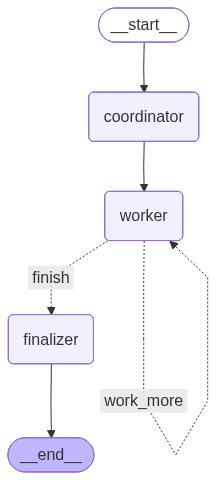

In [7]:
png_bytes = sentinel_coordinator.get_graph().draw_mermaid_png()

# Save to file
with open("sentinel_coordinator.png", "wb") as f:
    f.write(png_bytes)

# Display in notebook
display(Image(data=png_bytes))